In [1]:
import os
os.environ["OMP_NUM_THREADS"] = '1'  # KMeans memory leak

In [5]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import FloodAnalyzer

from utils.paths import HARMONISED_DATA_DIR
from utils import analogue_utils
from utils import flood_data_loader
from typing import Literal
from string import capwords
from cliffs_delta import cliffs_delta
from pycircstat2.hypothesis import wheeler_watson_test
from pycircstat2 import Circular
from scipy.stats import mannwhitneyu

Helper Functions

In [6]:
def circular_stat_from_xy(x, y, stat: Literal["std", "mean"]):
    """Compute circular mean or standard deviation from aggregated cos/sin components"""
    if stat == "mean":
        angle_rad = np.arctan2(y, x)
        angle_deg = (np.rad2deg(angle_rad)) % 360
        return angle_deg
    elif stat == "std":
        R = np.clip(np.sqrt(x**2 + y**2), 1e-12, 1.0)
        circ_std_rad = np.sqrt(-2 * np.log(R))
        circ_std_deg = np.rad2deg(circ_std_rad)
        return circ_std_deg
    else:
        raise ValueError("stat must be 'mean' or 'std'")


def circ_daily_stats(da: xr.DataArray, stat: Literal["std", "mean"]):
    """Compute daily circular mean or standard deviation from directional data in degrees"""
    radians = np.deg2rad(da)
    x = np.cos(radians).resample(time="1D").mean()  # type: ignore
    y = np.sin(radians).resample(time="1D").mean()  # type: ignore
    return circular_stat_from_xy(x, y, stat)


def circ_roll_stats(da: xr.DataArray, window: int,
                           stat: Literal["std", "mean"]):
    """Compute rolling circular mean or standard deviation from directional data in degrees."""
    radians = np.deg2rad(da)
    x = np.cos(radians).rolling(  # type: ignore
        time=window, center=False).mean()
    y = np.sin(radians).rolling(  # type: ignore
        time=window, center=False).mean()
    return circular_stat_from_xy(x, y, stat)


def is_circular_var(da_name: str):
    return "direction" in da_name.lower() and "onshore" not in da_name.lower()


# Data

In [7]:
flagged_months: list
flagged_months = flood_data_loader.load_flood_months()

flood_days_24 = ["2008-09-05", "2016-04-24", "2018-04-16",
                 "2018-09-25", "2021-11-07", "2023-09-19",
                 "2024-10-15"]
flood_months_24 = [day[:-3]
                   for day in flood_days_24]
flood_days_25 = ["2025-02-27", "2025-03-01"]
flood_months_25 = [day[:-3]
                   for day in flood_days_25]


In [8]:
dcfi_da, dcfi_components = analogue_utils.calculate_dcfi("2025-05-01")
dcfi_df = analogue_utils.calculate_daily_water_level(da=dcfi_da.sel(time=slice(None, "2024-12-31")),
                                                    temporal_agg="max",
                                                    spatial_agg="mean"
                                                    )
configs: list[FloodAnalyzer.ClusteringConfig] = [
    {'method': 'kmeans', 'n_clusters': 6},
]

clustered = FloodAnalyzer.ClusterFloodSignals(data=dcfi_df)
clustered.run(configs)
analyzer = FloodAnalyzer.ResultAnalyzer(clustered)

active_config = "kmeans_k6"
analyzer.active_config = active_config

In [9]:
def get_extreme_days(analyzer: FloodAnalyzer.ResultAnalyzer,
                     flood_days: list[str]):
    return (
        analyzer.extreme_days()
        [["month_str", "days"]]
        .assign(days=lambda df: df["days"].str.split(","))
        .explode("days")
        .assign(days=lambda df: df["days"].str.strip().replace("", np.nan))
        .dropna(subset=["days"])
        .assign(
            day=lambda df: pd.to_datetime(
                df["month_str"].str.cat(df["days"].str.zfill(2), sep="-")
            )
        )
        .reset_index(drop=True)
        .assign(is_flood_day=lambda df: df["day"].isin(flood_days).astype(int))
        .drop("days", axis=1)
    )


extreme_days_24 = get_extreme_days(analyzer,
                                   flood_days_24)
print(extreme_days_24.columns)
extreme_days_24.shape

Index(['month_str', 'day', 'is_flood_day'], dtype='object')


(692, 3)

In [10]:
def decluster_extreme_days(flood_days: list[str],
                           extreme_days: pd.DataFrame,
                           ):
    window = pd.Timedelta(days=3)
    to_drop = set()

    for fd in flood_days:
        fd = pd.to_datetime(fd)
        mask = (
            (extreme_days["day"] >= fd - window) &
            (extreme_days["day"] <= fd + window) &
            (extreme_days["day"] != fd)
        )

        to_drop.update(extreme_days.loc[mask].index)

    declustered_df = extreme_days.drop(index=list(to_drop))
    declustered_df = declustered_df.query("month_str.isin(@flagged_months)")

    return declustered_df


declustered_extreme_days_24 = decluster_extreme_days(flood_days_24,
                                                     extreme_days_24)

print(declustered_extreme_days_24.shape)
declustered_extreme_days_24["is_flood_day"].value_counts()


(102, 3)


is_flood_day
0    95
1     7
Name: count, dtype: int64

In [11]:
wind = xr.open_dataset(HARMONISED_DATA_DIR / "wind.nc")
wave_dir = xr.open_dataset(HARMONISED_DATA_DIR / "wave_direction.nc")

offset = 0.25
wind = wind.sel(latitude=slice(5-offset, 5.5+offset),
                longitude=slice(0.2-offset, 1.2+offset))
wave_dir = wave_dir.sel(latitude=slice(5-offset, 5.5+offset),
                        longitude=slice(0.2-offset, 1.2+offset*2))

climate_variables: dict[str, xr.DataArray] = {
    "DCFI": dcfi_da,
    "CWL": dcfi_components["cwl"].load(),
    "CWL_ROC": dcfi_components["cwl_roc"].load(),
    "DAC": dcfi_components["dac"]["max"].load(),
    "SLA": dcfi_components["sea"]["sla"].load(),
    "Tide": dcfi_components["tide"]["max"].load(),
    "Wave Run-up": dcfi_components["wave"]["run_up"].load(),
    "Wind Speed": wind["speed"],
    "Wind Direction": wind["direction"],
    "Wind Onshore": wind["onshore"],
    "Mean Wave Direction": wave_dir["mwd"],
    "Mean Wave Direction Onshore": wave_dir["mwd_onshore"],
    "Mean Direction Wind Waves": wave_dir["mdww"],
    "Mean Direction Wind Waves Onshore": wave_dir["mdww_onshore"],
    "Spread Diff": wave_dir["spread_diff"],
}
climate_variables = {k: v.sel(time=slice(None, "2025-05-01"))
                     for k, v in climate_variables.items()}

# Univariate Analysis

In [12]:
def process_climate_vars(start_date="1992-09-03", end_date="2024-12-31"):
    processed_da = []

    for name, da in climate_variables.items():
        if name.lower() in ["cwl", "cwl_roc", "dcfi", "dac",
                            "tide", "sla", "wave run-up", ]:
            continue

        _da = da.sel(time=slice(start_date, end_date)).copy(deep=True)
        _da = flood_data_loader.ensure_month_str_coord(_da)
        _da = _da.mean(["latitude", "longitude"])

        if is_circular_var(name):
            stats = {
                "mean": circ_daily_stats(_da, stat="mean"),
                "std": circ_daily_stats(_da, stat="std")
            }
        else:
            stats = {
                "mean": _da.resample(time="1D").mean(skipna=True),
                "max": _da.resample(time="1D").max(skipna=True),
                "min": _da.resample(time="1D").min(skipna=True),
                "std": _da.resample(time="1D").std(skipna=True),
            }

        for stat_name, stat_da in stats.items():
            valid = stat_da.notnull()
            stat_da = stat_da.where(valid, drop=True)
            stat_da.name = f"{capwords(name)} ({stat_name})"

            processed_da.append(stat_da)

    merged_da = xr.merge(processed_da, join="exact")

    merged_df = merged_da.to_dataframe()
    merged_df = merged_df.drop(["number", "surface", "meanSea"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df = merged_df.rename(columns={"time": "day"})

    return merged_df


other_vars = process_climate_vars()
other_vars = other_vars.sort_values("day").reset_index(drop=True)
other_vars = other_vars.reindex(sorted(other_vars.columns), axis=1)
other_vars.head()

,Mean Direction Wind Waves (mean),Mean Direction Wind Waves (std),Mean Direction Wind Waves Onshore (max),Mean Direction Wind Waves Onshore (mean),Mean Direction Wind Waves Onshore (min),Mean Direction Wind Waves Onshore (std),Mean Wave Direction (mean),Mean Wave Direction (std),Mean Wave Direction Onshore (max),Mean Wave Direction Onshore (mean),...,Wind Direction (std),Wind Onshore (max),Wind Onshore (mean),Wind Onshore (min),Wind Onshore (std),Wind Speed (max),Wind Speed (mean),Wind Speed (min),Wind Speed (std),day
0,216.373215,4.689165,0.073889,-0.095758,-0.202217,0.081307,192.533493,1.562449,-0.455526,-0.489142,...,5.021543,0.307916,0.206999,0.034563,0.085783,6.103264,5.594433,4.690638,0.366235,1992-09-03
1,219.457825,4.923507,0.153681,-0.042059,-0.167761,0.085325,190.804642,1.708014,-0.468755,-0.515445,...,5.022872,0.289343,0.173621,-0.028910,0.085539,5.985605,4.953651,4.317080,0.520571,1992-09-04
2,237.174393,5.816457,0.406771,0.260263,0.076612,0.097056,197.966309,3.368639,-0.307307,-0.404222,...,5.790871,0.043743,-0.148806,-0.313113,0.099077,7.942898,6.028592,4.926608,0.979025,1992-09-05
3,243.688812,9.235120,0.540110,0.364707,0.095456,0.149527,200.743927,2.758431,-0.293686,-0.359472,...,9.699219,0.014829,-0.263852,-0.451501,0.161782,7.158443,6.351440,5.552075,0.478850,1992-09-06
4,221.374542,7.006490,0.210766,-0.009317,-0.191834,0.120944,193.409302,1.271084,-0.434243,-0.476470,...,7.088375,0.260371,0.122869,-0.112723,0.122005,6.103631,5.013940,3.823501,0.636071,1992-09-07


In [13]:
def bootstrap_cliffs_delta(x, y, n_boot=1000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    n1, n2 = len(x), len(y)

    delta_obs, _ = cliffs_delta(x, y)
    boot_deltas = np.empty(n_boot)

    for i in range(n_boot):
        boot_x = rng.choice(x, size=n1, replace=True)
        boot_y = rng.choice(y, size=n2, replace=True)
        boot_deltas[i], _ = cliffs_delta(boot_x, boot_y)

    lower, upper = np.percentile(
        boot_deltas, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return delta_obs, lower, upper


uni_data = (declustered_extreme_days_24
            .merge(other_vars, "left", "day")
            .sort_values("day")
            .reset_index(drop=True)
            )
flood_day_filter = uni_data["is_flood_day"] == 1
univariate_results = []

for col in uni_data.columns:
    if col in ["month_str", "day", "is_flood_day"]:
        continue

    flood_data = uni_data.loc[flood_day_filter, col].values
    nonflood_data = uni_data.loc[~flood_day_filter, col].values

    is_std = "std" in col.lower()
    is_circular = is_circular_var(col)
    if is_circular and not is_std:  # get only directional variables
        flood_circ = Circular(flood_data, unit="degree")
        nonflood_circ = Circular(nonflood_data, unit="degree")

        U2, p = wheeler_watson_test(circs=[flood_circ, nonflood_circ])
        result = {"variable": col,
                  "p_value": p}

    else:
        c_delta, c_category = cliffs_delta(flood_data, nonflood_data)
        delta_obs, ci_low, ci_high = bootstrap_cliffs_delta(
            flood_data, nonflood_data, n_boot=5000)

        stat, p = mannwhitneyu(flood_data, nonflood_data)

        result = {
            "variable": col,
            "p_value": p,
            "cliffs_delta": round(delta_obs, 2),
            "delta_ci_low": ci_low.round(2),
            "delta_ci_high": ci_high.round(2),
            "cliffs_category": c_category,
        }
    univariate_results.append(result)

uni_scores = (pd.DataFrame(univariate_results)
    .sort_values("p_value")
    .reset_index(drop=True)
    .assign(cliff_delta=lambda df: (df['cliffs_delta'].astype(str)
                                    + " [" + df["delta_ci_low"].astype(str)
                                    + ", " + df["delta_ci_high"].astype(str)
                                    + "]"
                                    )
            )
    .round(3))
uni_scores

,variable,p_value,cliffs_delta,delta_ci_low,delta_ci_high,cliffs_category,cliff_delta
0,Spread Diff (min),0.009,-0.58,-0.86,-0.19,large,"-0.58 [-0.86, -0.19]"
1,Spread Diff (mean),0.010,-0.57,-0.88,-0.21,large,"-0.57 [-0.88, -0.21]"
2,Wind Onshore (std),0.020,0.52,0.23,0.78,large,"0.52 [0.23, 0.78]"
3,Mean Direction Wind Waves (std),0.025,0.50,0.18,0.80,large,"0.5 [0.18, 0.8]"
4,Wind Direction (std),0.032,0.48,0.19,0.74,large,"0.48 [0.19, 0.74]"
5,Mean Direction Wind Waves Onshore (std),0.036,0.47,0.20,0.73,medium,"0.47 [0.2, 0.73]"
6,Spread Diff (std),0.049,0.45,-0.06,0.82,medium,"0.45 [-0.06, 0.82]"
7,Mean Wave Direction (std),0.081,-0.40,-0.91,0.16,medium,"-0.4 [-0.91, 0.16]"
8,Mean Wave Direction Onshore (std),0.093,-0.38,-0.89,0.18,medium,"-0.38 [-0.89, 0.18]"
9,Mean Direction Wind Waves Onshore (min),0.107,-0.37,-0.70,-0.02,medium,"-0.37 [-0.7, -0.02]"


In [30]:
uni_scores.query("p_value < 0.05")

,variable,p_value,cliffs_delta,delta_ci_low,delta_ci_high,cliffs_category,cliff_delta
0,Spread Diff (min),0.009,-0.58,-0.86,-0.19,large,"-0.58 [-0.86, -0.19]"
1,Spread Diff (mean),0.010,-0.57,-0.88,-0.21,large,"-0.57 [-0.88, -0.21]"
2,Wind Onshore (std),0.020,0.52,0.23,0.78,large,"0.52 [0.23, 0.78]"
3,Mean Direction Wind Waves (std),0.025,0.50,0.18,0.80,large,"0.5 [0.18, 0.8]"
4,Wind Direction (std),0.032,0.48,0.19,0.74,large,"0.48 [0.19, 0.74]"
5,Mean Direction Wind Waves Onshore (std),0.036,0.47,0.20,0.73,medium,"0.47 [0.2, 0.73]"
6,Spread Diff (std),0.049,0.45,-0.06,0.82,medium,"0.45 [-0.06, 0.82]"


# Identifying Flood-Analogue Days

In [14]:
def preprocess_da(da: xr.DataArray, name: str,
                  start_date="1992-09-03", end_date="2025-12-31"):
    da.name = name.lower()
    da = da.mean(["latitude", "longitude"])
    da = da.sel(time=slice(start_date, end_date))
    return da


da_list = [preprocess_da(da, name) for name, da in climate_variables.items()]
ds = xr.merge(da_list, join="exact")

In [15]:
def get_daily_stats(ds: xr.Dataset, extreme_days: list | None,
                    flood_dates: list):
    ds_stats = {
        "max": ds.resample(time="1D").max(),
        "min": ds.resample(time="1D").min(),
    }

    std_dict = {}
    mean_dict = {}
    for name, da in ds.items():
        if is_circular_var(str(name)):
            std_dict[str(name)] = circ_daily_stats(da, "std")
            mean_dict[str(name)] = circ_daily_stats(da, "mean")
        else:
            std_dict[str(name)] = da.resample(time="1D").std()
            mean_dict[str(name)] = da.resample(time="1D").mean()

    ds_stats["std"] = xr.Dataset(std_dict)
    ds_stats["mean"] = xr.Dataset(mean_dict)

    ds_subset = ({key: value.sel(time=extreme_days)
                  for key, value in ds_stats.items()}
                 if extreme_days is not None
                 else ds_stats.copy())

    df_list = [value.to_dataframe().reset_index().assign(stat=key)
               for key, value in ds_subset.items()]

    daily_stats = (pd.concat(df_list)
                   .sort_values(["time", "stat"])
                   .reset_index(drop=True)
                   .assign(is_flood_day=lambda df: df["time"].isin(flood_dates))
                   .drop(["number", "surface", "meanSea"], axis=1)
                   )
    return daily_stats, ds_stats, ds_subset


daily_stats, ds_stats, _ = get_daily_stats(ds,
                                           None,  # noqa
                                           flood_days_24)
daily_stats.shape

(47716, 18)

In [16]:
def make_daily_stats_wide(daily_stats):
    daily_wide = (
        daily_stats
        # one row per date, columns per stat
        .pivot(index="time", columns="stat")
        .reset_index()
    )

    # Flatten the multi-index column names created by pivot
    daily_wide.columns = [
        f"{col[0]}_{col[1]}" if col[1] else col[0]
        for col in daily_wide.columns
    ]
    is_flood_cols = [
        c for c in daily_wide.columns if c.startswith("is_flood_day")]
    daily_wide["is_flood_day"] = daily_wide[is_flood_cols].any(axis=1)

    # Drop redundant is_flood_day columns
    daily_wide = daily_wide.drop(columns=is_flood_cols)
    daily_wide.sort_values("time", inplace=True)
    return daily_wide


daily_wide = make_daily_stats_wide(daily_stats)
daily_wide.shape

(11929, 62)

In [17]:
significant_vars = [
    ("spread diff", "std",),
    ("spread diff", "min",),
    ("wind onshore", "std"),
    ("mean direction wind waves", "std"),
    ("wind direction", "std"),
    ("mean direction wind waves onshore", "std"),
]
lagged_vars = [
    ("spread diff", "std",),
    ("spread diff", "min",),
    ("wind onshore", "std"),
    ("mean direction wind waves", "std"),
    ("wind direction", "std"),
    ("mean direction wind waves onshore", "std"),
]

composite_vars = [
    [("spread diff", "mean"), ("spread diff", "min")]

]

In [18]:
def derive_envelopes(daily_stats: pd.DataFrame,
                     significant_vars,
                     expansion=0.05):
    flood_days = daily_stats.query("is_flood_day")
    envelopes = {}

    for var, stat in significant_vars:
        subset = flood_days.query("stat == @stat")[var]

        q_low, q_high = subset.quantile([0.05, 0.95])

        span = q_high - q_low
        lower = q_low - expansion * span
        upper = q_high + expansion * span

        envelopes[f"{var}_{stat}"] = {
            "variable": var,
            "stat": stat,
            "lower": lower,
            "upper": upper,
            # "n": len(subset),
        }

    return envelopes

In [19]:
# pd.DataFrame.from_dict(derive_envelopes(daily_stats, significant_vars, 0.033), orient="index").round(3)

In [20]:
def get_potential_flood_days(significant_vars,
                             daily_wide,
                             envelopes,
                             extreme_days,
                             flood_months: list[str],
                             n_required=5,
                             only_flagged=True,
                             include_lag=False,
                             lagged_vars=None):
    for var, stat in significant_vars:
        col = f"{var}_{stat}"
        if col not in daily_wide.columns:
            raise KeyError(f"Column {col} missing in daily_wide")
        if col not in envelopes:
            raise KeyError(f"Envelope {col} missing in envelopes dictionary")

    if lagged_vars is None:
        lagged_vars = []

    within_env = {}
    for var, stat in significant_vars:
        col = f"{var}_{stat}"
        env = envelopes[col]

        mask = ((daily_wide[col] >= env["lower"])
                & (daily_wide[col] <= env["upper"]))

        if include_lag and (var, stat) in lagged_vars:
            mask = mask | mask.shift(1)

        within_env[col] = mask

    within_env_df = pd.DataFrame(within_env, index=daily_wide.index)

    within_env_df = (within_env_df
                     .assign(n_within_envelope=lambda df: df.sum(axis=1),
                             is_flood_like=lambda df: df["n_within_envelope"] >= n_required,  # noqa
                             day=daily_wide["time"],
                             )
                     )

    flood_months = pd.to_datetime(flood_months).to_period("M")
    within_env_df = (within_env_df
                     .merge(extreme_days, "right", on="day")
                     .assign(is_flood_month=lambda df: df["day"].dt.to_period("M").isin(flood_months))
                     )

    if only_flagged:
        within_env_df = within_env_df.query("is_flood_like")

    return within_env_df

In [21]:
results_grid = []

for exp in [0.00, 0.033, 0.066, 0.10]:
    envs = derive_envelopes(daily_stats, significant_vars, expansion=exp)
    for n_req in [2, 3, 4, 5,6]:
        df = get_potential_flood_days(
            significant_vars,
            daily_wide,
            envs,
            extreme_days_24,
            flagged_months,
            n_required=n_req,
            only_flagged=False,
            include_lag=True,
            lagged_vars=lagged_vars,
        )
        n_flagged = df.loc[df["is_flood_like"], "day"].nunique()
        n_floods_captured = df.loc[
            df["is_flood_like"] & df["is_flood_day"], "day"
        ].nunique()
        n_nonflood_flagged = n_flagged - n_floods_captured

        results_grid.append({
            "expansion": exp,
            "n_required": n_req,
            "flagged_days": int(n_flagged),
            "known_floods_detected": int(n_floods_captured),
            "nonfloods_flagged": int(n_nonflood_flagged)
        })

results_grid_df = pd.DataFrame(results_grid)
# results_grid_df

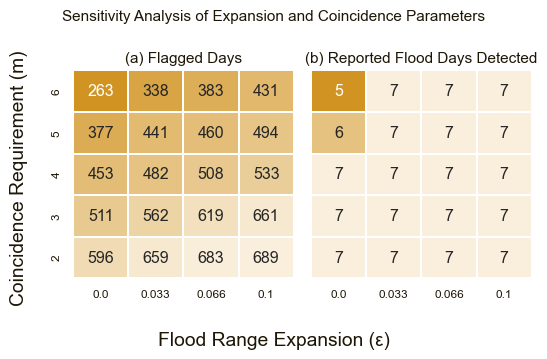

In [22]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_gradient", ["#D19423", "#F9EFDC"]
)


def plot_heatmap(ax, df, value_col, title, cmap):
    """Helper function to create a single heatmap."""
    pivot = (
        df.pivot(index="n_required", columns="expansion", values=value_col)
        .sort_index(ascending=False)
    )
    sns.heatmap(
        pivot,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        linewidths=0.09,
        # linecolor='gray',
        ax=ax,
        cbar=False,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")


fig, axes = plt.subplots(1, 2, figsize=(5.5, 3.5), sharey=True)

plots = [
    {
        "value_col": "flagged_days",
        "title": "(a) Flagged Days",
        "cmap": "Greens",
    },
    {
        "value_col": "known_floods_detected",
        "title": "(b) Reported Flood Days Detected",
        "cmap": "Greens",
    }
]

# Loop through both subplots
for ax, cfg in zip(axes, plots):
    plot_heatmap(ax, results_grid_df,
                 cfg["value_col"], cfg["title"], cfg["cmap"])


fig.suptitle("Sensitivity Analysis of Expansion and Coincidence Parameters", )
fig.supylabel("Coincidence Requirement (m)")
fig.supxlabel("Flood Range Expansion (ε)")
plt.tight_layout()
plt.show()

In [23]:
valid = results_grid_df.query("known_floods_detected == 7")

if not valid.empty:
    best = valid.sort_values("flagged_days").iloc[0]
    print(best)
else:
    print("No combination captures all 7 floods.")

expansion                  0.033
n_required                 6.000
flagged_days             338.000
known_floods_detected      7.000
nonfloods_flagged        331.000
Name: 9, dtype: float64


In [24]:
envelopes = derive_envelopes(daily_stats,
                             significant_vars,
                             expansion=0.033)
potential_flood_days = get_potential_flood_days(significant_vars,
                                                daily_wide,
                                                envelopes,
                                                extreme_days_24,
                                                flagged_months,
                                                n_required=6,
                                                only_flagged=True,
                                                include_lag=True,
                                                lagged_vars=lagged_vars,)
potential_flood_days

,spread diff_std,spread diff_min,wind onshore_std,mean direction wind waves_std,wind direction_std,mean direction wind waves onshore_std,n_within_envelope,is_flood_like,day,month_str,is_flood_day,is_flood_month
2,True,True,True,True,True,True,6,True,1993-01-18,1993-01,0,False
5,True,True,True,True,True,True,6,True,1993-05-05,1993-05,0,False
10,True,True,True,True,True,True,6,True,1993-08-18,1993-08,0,False
11,True,True,True,True,True,True,6,True,1993-08-19,1993-08,0,False
12,True,True,True,True,True,True,6,True,1993-09-15,1993-09,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
674,True,True,True,True,True,True,6,True,2024-05-22,2024-05,0,False
675,True,True,True,True,True,True,6,True,2024-06-27,2024-06,0,False
676,True,True,True,True,True,True,6,True,2024-06-28,2024-06,0,False
688,True,True,True,True,True,True,6,True,2024-10-15,2024-10,1,True


In [25]:
(potential_flood_days
 .query("is_flood_month & is_flood_like")
 .groupby("month_str")
 .apply(lambda row: ", ".join(row["day"].dt.strftime("%d")))
 .reset_index()
 .assign(month_str=lambda df: pd.to_datetime(df["month_str"]).dt.strftime("%B %Y"))
 )

,month_str,0
0,September 2006,"21, 25"
1,July 2007,"29, 30"
2,September 2008,"04, 05"
3,September 2009,"19, 20, 21"
4,May 2010,"13, 14"
5,August 2010,"11, 16"
6,August 2014,26
7,June 2015,"01, 02, 04"
8,September 2015,"27, 28, 29, 30"
9,April 2016,"07, 08, 23, 24, 25"


## 2025 Validation

In [26]:
k_means = analyzer.config_results["cluster_model"]
dcfi_2025_df = analogue_utils.calculate_daily_water_level(da=dcfi_da.sel(time=slice("2025-01-01", None)),
                                                          temporal_agg="max",
                                                          spatial_agg="mean")
configs_2025: list[FloodAnalyzer.ClusteringConfig] = [
    {'method': 'kmeans', 'n_clusters': 6, "model": k_means},
]
clustered_2025 = FloodAnalyzer.ClusterFloodSignals(data=dcfi_2025_df)
clustered_2025.run(configs_2025)
analyzer_2025 = FloodAnalyzer.ResultAnalyzer(clustered_2025)

active_config = "kmeans_k6_pretrained"
analyzer_2025.active_config = active_config

In [27]:
extreme_days_25 = get_extreme_days(analyzer_2025, flood_days_25)
analyzer_2025.extreme_days()

,month_str,days,n_days,gpd_major_days,gpd_moderate_days,gpd_minor_days
0,2025-01,,NaN,,,
1,2025-02,"27, 28",2.0,,,
2,2025-03,"1, 29, 30, 31",4.0,31,,1
3,2025-04,1,1.0,,,
4,2025-05,,NaN,,,


In [28]:
da_2025_list = [preprocess_da(da, name, start_date="2025-01-01")
                for name, da in climate_variables.items()]
ds_2025 = xr.merge(da_2025_list, join="exact")

daily_stats_2025, ds_stats_2025, _ = get_daily_stats(ds_2025,
                                                    None,  # noqa
                                           flood_days_25)
daily_wide_2025 = make_daily_stats_wide(daily_stats_2025)

In [29]:
potential_flood_days = get_potential_flood_days(significant_vars,
                                                daily_wide_2025,
                                                envelopes,
                                                extreme_days_25,
                                                flood_months_25,
                                                n_required=6,
                                                only_flagged=True,
                                                include_lag=True,
                                                lagged_vars=lagged_vars,)
potential_flood_days

,spread diff_std,spread diff_min,wind onshore_std,mean direction wind waves_std,wind direction_std,mean direction wind waves onshore_std,n_within_envelope,is_flood_like,day,month_str,is_flood_day,is_flood_month
0,True,True,True,True,True,True,6,True,2025-02-27,2025-02,1,True
1,True,True,True,True,True,True,6,True,2025-02-28,2025-02,0,True
2,True,True,True,True,True,True,6,True,2025-03-01,2025-03,1,True
3,True,True,True,True,True,True,6,True,2025-03-29,2025-03,0,True
